# Parking Detection Model

This notebook demonstrates how the trained YOLO model is used for detecting cars and analyzing parking scenarios.

The workflow includes:
- Loading the trained model
- Running inference on images or videos
- Visualizing detection results

In [ ]:
from google.colab import files
import zipfile, os



u = files.upload()
zip_name = list(u.keys())[0]

with zipfile.ZipFile(zip_name) as z:
    z.extractall('/content/parking_slots')


!ls /content/parking_slots

Saving Car_Parking.zip to Car_Parking.zip
'Car Parking'   __MACOSX


In [ ]:
!ls /content/parking_slots/
!echo "---"
!ls /content/parking_slots/parking-detection-data/train/

'Car Parking'   __MACOSX
---
ls: cannot access '/content/parking_slots/parking-detection-data/train/': No such file or directory


## Explore Dataset Structure

This cell is used to explore the structure of the extracted parking slots dataset.

It performs the following:
- Walks through all folders and subfolders  
- Skips system folders like `__MACOSX`  
- Displays directory hierarchy in a structured format  
- Shows the number of files in each folder  

This helps verify that the dataset is organized correctly before using it.

In [ ]:
import os

for root, dirs, files in os.walk('/content/parking_slots/Car_Parking'):
    if '__MACOSX' in root:
        continue
    level = root.replace('/content/parking_slots/Car_Parking', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')

## Check Dataset Files

This cell inspects the contents of the training dataset folder.

It performs the following:
- Lists all files inside the training directory  
- Extracts file extensions to understand data types (e.g., jpg, png)  
- Displays a few sample file names  

This helps verify that the dataset is correctly loaded and formatted before training or processing.

In [ ]:
import os

train_path = '/content/parking_slots/Car Parking/train'
files = os.listdir(train_path)

extensions = set(f.split('.')[-1] for f in files)
print("Extensions:", extensions)

print("\nSample files:")
for f in files[:4]:
    print(f)

Extensions: {'json', 'jpg'}

Sample files:
4k-time-lapse-car-parking-lot-stock-video-download-video-clip-now-istock_TyROSAGZ_mp4-618_jpg.rf.2fd6163ed975e0f21d577417e7df4f55.jpg
4k-time-lapse-car-parking-lot-stock-video-download-video-clip-now-istock_TyROSAGZ_mp4-556_jpg.rf.cabebfee6a29a0f1b806c1586b12a3c8.jpg
KakaoTalk_20230515_182152064_22_jpg.rf.7e550ee16bb68d2d5c1a281ca45b527d.jpg
KakaoTalk_20230515_201418099_12_jpg.rf.f519c25d8ff6a4b1459098b441eb437a.jpg


## Inspect COCO Annotations

This cell loads and explores the dataset annotations in COCO format.

It performs the following:
- Reads the JSON annotation file  
- Displays the main keys in the dataset  
- Shows available categories (e.g., car)  
- Counts the total number of images and annotations  
- Prints a sample annotation  

This step is important to understand the dataset structure before converting it to YOLO format or using it for training.

In [ ]:
import json

with open('/content/parking_slots/Car Parking/train/_annotations.coco.json') as f:
    data = json.load(f)

print("Keys:", list(data.keys()))
print("Categories:", data['categories'])
print("Total images:", len(data['images']))
print("Total annotations:", len(data['annotations']))

print("\nSample annotation:")
print(data['annotations'][0])

Keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Categories: [{'id': 0, 'name': 'cars', 'supercategory': 'none'}, {'id': 1, 'name': 'busy', 'supercategory': 'cars'}, {'id': 2, 'name': 'empty', 'supercategory': 'cars'}]
Total images: 1535
Total annotations: 32315

Sample annotation:
{'id': 1, 'image_id': 0, 'category_id': 2, 'bbox': [181, 356, 170.201, 77.133], 'area': 13128.23, 'segmentation': [[180.566, 382.364, 211.762, 433.214, 350.767, 401.598, 276.36, 356.08, 180.566, 382.364]], 'iscrowd': 0}


In [ ]:
for ann in data['annotations'][:3]:
    print(ann)
    print()

{'id': 1, 'image_id': 0, 'category_id': 2, 'bbox': [181, 356, 170.201, 77.133], 'area': 13128.23, 'segmentation': [[180.566, 382.364, 211.762, 433.214, 350.767, 401.598, 276.36, 356.08, 180.566, 382.364]], 'iscrowd': 0}

{'id': 2, 'image_id': 0, 'category_id': 1, 'bbox': [23, 258, 190.466, 224.723], 'area': 42802.033, 'segmentation': [[178.273, 334.943, 160.018, 258.26, 85.149, 261.95, 66.2, 325.922, 61.81, 362.418, 50.949, 405.066, 23.162, 482.983, 213.628, 435.411, 181.97, 381.282, 178.273, 334.943]], 'iscrowd': 0}

{'id': 3, 'image_id': 0, 'category_id': 1, 'bbox': [277, 257, 188.578, 145.576], 'area': 27452.443, 'segmentation': [[350.329, 402.598, 465.868, 381.274, 453.128, 371.413, 448.803, 299.934, 434.442, 267.273, 404.171, 257.022, 352.64, 266.043, 319.365, 313.612, 315.437, 349.698, 277.29, 355.079, 350.329, 402.598]], 'iscrowd': 0}



## Convert COCO Annotations to YOLO Format

This cell converts dataset annotations from **COCO format** to **YOLO format**.

### What this step does:

- Iterates over dataset splits:
  - `train`
  - `valid`
  - `test`

- Loads COCO annotation file (`_annotations.coco.json`) for each split  

- Extracts:
  - Image information (width, height, file name)  
  - Bounding boxes for selected classes  

- Filters annotations to include only specific categories (`category_id` in [1, 2])  

- Converts bounding boxes from COCO format:

In [ ]:
import json, os
from pathlib import Path
from collections import defaultdict

for split in ['train', 'valid', 'test']:
    json_path = f'/content/parking_slots/Car Parking/{split}/_annotations.coco.json'
    img_dir   = f'/content/parking_slots/Car Parking/{split}'
    label_dir = f'/content/parking_data/{split}/labels'
    img_out   = f'/content/parking_data/{split}/images'

    os.makedirs(label_dir, exist_ok=True)
    os.makedirs(img_out,   exist_ok=True)

    with open(json_path) as f:
        data = json.load(f)

    img_map = {img['id']: img for img in data['images']}

    ann_map = defaultdict(list)
    for ann in data['annotations']:
        if ann['category_id'] in [1, 2]:
            ann_map[ann['image_id']].append(ann)

    for img_id, anns in ann_map.items():
        img_info = img_map[img_id]
        W, H = img_info['width'], img_info['height']
        fname = img_info['file_name']

        lines = []
        for ann in anns:
            cls = 2 - ann['category_id']
            x, y, w, h = ann['bbox']
            cx = (x + w/2) / W
            cy = (y + h/2) / H
            nw = w / W
            nh = h / H
            lines.append(f"{cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        label_file = os.path.join(label_dir, fname.replace('.jpg', '.txt'))
        with open(label_file, 'w') as f:
            f.write('\n'.join(lines))

        src = os.path.join(img_dir, fname)
        dst = os.path.join(img_out, fname)
        if not os.path.exists(dst):
            os.symlink(src, dst)

    print(f"✅ {split}: {len(ann_map)} images processed")

✅ train: 1535 images processed
✅ valid: 243 images processed
✅ test: 122 images processed


## ⚙️ Create YOLO Configuration File (data.yaml)

This cell creates the `data.yaml` file required for training YOLO models.

### What this file defines:

- **path**: Root directory of the dataset  
- **train / val / test**: Paths to image folders for each split  
- **nc**: Number of classes  
- **names**: Class labels  

### In this project:
- `empty` → empty parking slot  
- `occupied` → occupied parking slot  

---

### Why this step is important:

- YOLO requires a `data.yaml` file to understand dataset structure  
- It connects images and labels to the training process  
- Defines the classes used in detection  

This file is essential before starting model training.

In [ ]:
# data.yaml
yaml_content = """
path: /content/parking_data
train: train/images
val: valid/images
test: test/images

nc: 2
names: ['empty', 'occupied']
"""

with open('/content/parking_data/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml created")

✅ data.yaml created


In [ ]:
!pip install ultralytics -q

##  Train YOLO Model (Fine-Tuning)

This cell trains the YOLO model using **fine-tuning** on the parking dataset.

### What is happening here:

- A pretrained YOLO model (`yolo26s.pt`) is loaded  
- The model is retrained on a custom dataset (`parking_data`)  
- This process is known as **Transfer Learning + Fine-Tuning**

---

### Training Configuration:

- **data**: Path to dataset configuration file (`data.yaml`)  
- **epochs = 30**: Number of training iterations  
- **imgsz = 640**: Input image resolution  
- **batch = 16**: Number of images per batch  

---

### Fine-Tuning Settings:

- **freeze = 5**  
  - Freezes the first 5 layers of the model  
  - Preserves general features learned from COCO  
  - Only higher layers are updated  

- **lr0 = 0.0001**  
  - Low learning rate for stable fine-tuning  
  - Prevents large changes to pretrained weights  

---

### Output Settings:

- **project**: Directory to save training results  
- **name**: Folder name for this experiment  

---

### Why this step is important:

- Adapts a general object detection model to a **specific task (parking detection)**  
- Improves performance using domain-specific data  
- Enables the model to detect:
  - Parking occupancy (empty / occupied)  

---

### Key Insight:

> Fine-tuning allows the model to reuse learned features while adapting to new data, improving generalization and performance.

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo26s.pt')

model.train(
    data='/content/parking_data/data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    freeze=5,
    lr0=0.0001,
    project='/content/parking_runs',
    name='parking_slots',
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/parking_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking_slots, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e57800df5c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

## Model Evaluation

This cell evaluates the trained model on the test dataset.

Metrics:
- **mAP@50**: overall performance  
- **Precision**: correctness of detections  
- **Recall**: ability to detect all objects  

In [ ]:
metrics = model.val(
    data='/content/parking_data/data.yaml',
    split='test',
)

print(f"mAP@50: {metrics.box.map50:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall: {metrics.box.mr:.3f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2508.6±433.2 MB/s, size: 94.1 KB)
val: Scanning /content/parking_data/test/labels... 122 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122 2.2Kit/s 0.1s
val: New cache created: /content/parking_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.0it/s 2.6s
                   all        122       3286      0.968      0.955      0.984       0.87
                 empty        119       1030      0.952      0.928      0.975      0.817
              occupied        114       2256      0.984      0.982      0.994      0.923
Speed: 1.4ms preprocess, 10.4ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50: 0.984
Precision: 0

## Inference on New Image

This cell tests the trained model on a new image.

- Upload an image  
- Run prediction using YOLO  
- Display the detected result  

Saving IMG_0863.jpg to IMG_0863.jpg

image 1/1 /content/IMG_0863.jpg: 384x640 8 emptys, 3 occupieds, 6.9ms
Speed: 1.5ms preprocess, 6.9ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


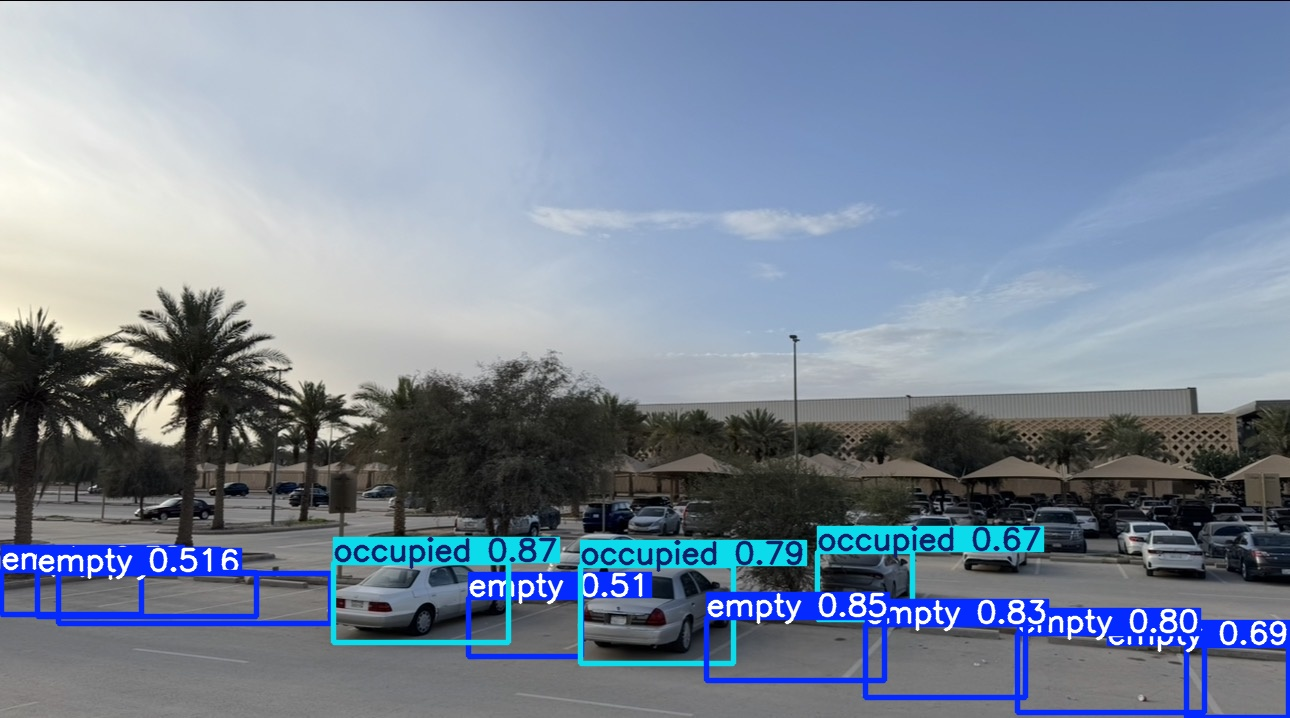

In [ ]:
from google.colab import files
from IPython.display import Image, display
import os

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

results = model.predict(img_path, conf=0.2, save=True)

save_dir = str(results[0].save_dir)
display(Image(f"{save_dir}/{img_path}"))

## Video Inference

This cell runs the model on a video.

- Upload a video  
- Apply YOLO detection  
- Display and download the output video  

In [ ]:
from google.colab import files
from IPython.display import Video, display

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

results = model.predict(
    video_path,
    conf=0.3,
    save=True,
    project='/content/runs/video',
    name='test'
)

output_video = '/content/runs/video/test/' + video_path
display(Video(output_video, embed=True))

files.download('/content/runs/video/test/' + video_path)

Saving car parking.mov to car parking (1).mov

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/651) /content/car parking (1).mov: 352x640 5 emptys, 3 occupieds, 6.7ms
video 1/1 (frame 2/651) /content/car parking (1).mov: 352x640 5 emptys, 3 occupieds, 6.1ms
video 1/1 (frame 3/651) /content/car parking (1).mov: 352x640 5 emptys, 3 occupieds, 5.7ms
video 1/1 (frame 4/651) /content/car parking (1).mov: 352x640 5 emptys, 3 occupieds, 5.2ms
video 1/1 (frame 5/651) /content/car parking (1)

FileNotFoundError: Cannot find file: /content/runs/video/test/car parking (1).mov

In [ ]:
import glob

# دور على الفيديو
videos = glob.glob('/content/runs/video/test/**/*', recursive=True)
for v in videos:
    print(v)

/content/runs/video/test/car parking.avi


In [ ]:
from google.colab import files
files.download('/content/runs/video/test/car parking.avi')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

shutil.copy('/content/parking_runs/parking_slots/weights/best.pt',
            '/content/parking_slots_detector.pt')

files.download('/content/parking_slots_detector.pt')
print("✅ Done")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done


##  Conclusion

The trained YOLO model achieved strong performance on the test dataset:

- **mAP@50**: 0.984  
- **Precision**: 0.968  
- **Recall**: 0.955  

These results indicate that the model is highly accurate, with very few false detections and minimal missed parking slots.

The model demonstrates strong generalization and is suitable for real-world parking analysis tasks.

Future improvements may include:
- Expanding the dataset for more complex scenarios  
- Enhancing detection under challenging conditions  
- Integrating the system into a real-time application  